# CISA Known Exploited Vulnerabilities (KEV) Analysis
Data source: The Cybersecurity and Infrastructure Security Agency's [Known Exploited Vulnerabilities (KEV) catalog](https://github.com/cisagov/kev-data?)

## Step 1: Import Libraries

In [23]:
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns

## Step 2: Load the Data

In [24]:
# Get the .csv data from GitHub
data_url = "https://raw.githubusercontent.com/cisagov/kev-data/refs/heads/develop/known_exploited_vulnerabilities.csv"
kev = pd.read_csv(data_url)

# Save a local copy
kev.to_csv("known_exploited_vulnerabilities.csv", index=False)
kev = pd.read_csv("known_exploited_vulnerabilities.csv")

print(kev.head(30))

             cveID       vendorProject                             product  \
0   CVE-2026-48908          JoomShaper                     SP Page Builder   
1   CVE-2026-55255            Langflow                            Langflow   
2   CVE-2026-56290            Joomlack                        Page Builder   
3   CVE-2026-48282               Adobe                          ColdFusion   
4   CVE-2026-45659           Microsoft                   SharePoint Server   
5   CVE-2026-48558         SimpleHelp                           SimpleHelp   
6   CVE-2026-12569                 PTC               Windchill and FlexPLM   
7   CVE-2026-20230               Cisco      Unified Communications Manager   
8   CVE-2025-67038           Lantronix                             EDS5000   
9   CVE-2026-34910            Ubiquiti                            UniFi OS   
10  CVE-2026-34909            Ubiquiti                            UniFi OS   
11  CVE-2026-34908            Ubiquiti                          

## Step 3: Read the Data Documentation 
### Shema
#### (Extracted from known_exploited_vulnerabilities_schema.json)

| Column | Description |
| :--- | ---: | 
| cveID | The CVE ID of the vulnerability in the format CVE-YYYY-NNNN, note that the number portion can have more than 4 digits |
| vendorProject | The vendor or project name for the vulnerability |
| product | The vulnerability product |
| vulnerabilityName | The name of the vulnerability |
| dateAdded | The date the vulnerability was added to the catalog in the format YYYY-MM-DD |
| shortDescription | A short description of the vulnerability |
| requiredAction | The required action to address the vulnerability |
| dueDate | The date the required action is due in the format YYYY-MM-DD |
| knownRansomwareCampaignUse | 'Known' if this vulnerability is known to have been leveraged as part of a ransomware campaign; 'Unknown' if CISA lacks confirmation that the vulnerability has been utilized for ransomware |
| notes | Any additional notes about the vulnerability |
| cwes | Common Weakness Enumeration (CWE) codes associated with this vulnerability. CWEs are in the format CWE-NNNN; note that the number portion can have any number of digits |


## Step 4: Inspect the Data

In [25]:
print(kev.info())
print()
print()
print(kev.describe(include="all"))
print()
print()
kev.duplicated().sum()

<class 'pandas.DataFrame'>
RangeIndex: 1635 entries, 0 to 1634
Data columns (total 11 columns):
 #   Column                      Non-Null Count  Dtype
---  ------                      --------------  -----
 0   cveID                       1635 non-null   str  
 1   vendorProject               1635 non-null   str  
 2   product                     1635 non-null   str  
 3   vulnerabilityName           1635 non-null   str  
 4   dateAdded                   1635 non-null   str  
 5   shortDescription            1635 non-null   str  
 6   requiredAction              1635 non-null   str  
 7   dueDate                     1635 non-null   str  
 8   knownRansomwareCampaignUse  1635 non-null   str  
 9   notes                       1635 non-null   str  
 10  cwes                        1464 non-null   str  
dtypes: str(11)
memory usage: 140.6 KB
None


                 cveID vendorProject  product  \
count             1635          1635     1635   
unique            1635           272      662

np.int64(0)

## Step 5: Clean the Data
Before analysis, I cleaned the dataset by renaming columns to snake_case and converting date columns to datetime objects.

In [26]:
# Rename columns to match Python's snake_case convention
kev.rename(columns={
    "cveID": "cve_id",
    "vendorProject": "vendor_project",
    "vulnerabilityName": "vulnerability_name",
    "dateAdded": "date_added",
    "shortDescription": "short_description",
    "requiredAction": "required_action",
    "dueDate": "due_date",
    "knownRansomwareCampaignUse": "known_ransomware_campaign_use"
}, inplace=True)

#print(kev.columns)



# Covert values in date_added and due_date from strings to dates
kev["date_added"] = pd.to_datetime(kev["date_added"])
kev["due_date"] = pd.to_datetime(kev["due_date"])

#print(kev.info())

## Step 6: Explore the Data
### Which vendors have the greatest number of known vulnerabilities?

In [27]:
# Make a dataframe of the ten vendors with the most known vulnerabilities and the corresponding number of vulnerabilities

top_vendors = (
    kev["vendor_project"]
    .value_counts()
    .head(10)
    .reset_index()
)

print(top_vendors)

  vendor_project  count
0      Microsoft    378
1          Cisco     93
2          Apple     93
3          Adobe     80
4         Google     72
5         Oracle     44
6         Apache     39
7         Ivanti     35
8          Linux     26
9         D-Link     26


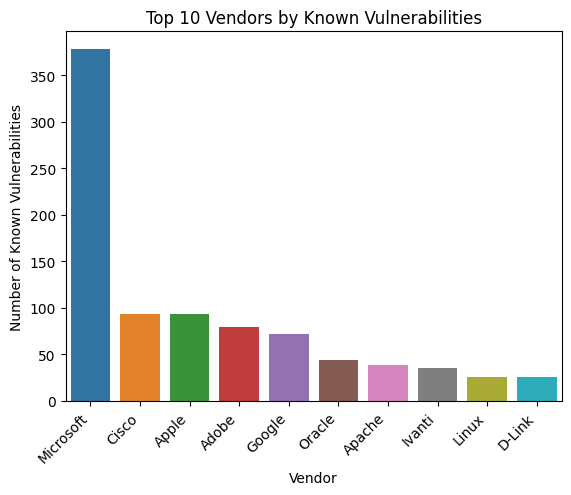

In [28]:
# Plot a bar chart showing the "Top 10 Vendors by Known Vulnerabilities"

sns.barplot(x="vendor_project",
    y="count", 
    hue="vendor_project",
    data=top_vendors,
    palette="tab10",
    legend=False
)

plt.xticks(rotation=45, ha="right")
plt.xlabel("Vendor")
plt.ylabel("Number of Known Vulnerabilities")
plt.title("Top 10 Vendors by Known Vulnerabilities")

plt.show()
plt.close()

Amongst the top ten vendors with the most vulnerabilities, most vendors have 25 to 100 known vulnerabilities. Microsoft appears to be an outlier, with over 350 known vulnerabilities. 
The vendors with the most known vulnerabilities are large vendors that produce a wide variety and a great number of products. The large scale of these vendors could help explain why their products have a greater number of known vulnerabilities overall. 
In addition, variation in vendor reporting practices could explain why some vendors appear to have more known vulnerabilities than others. These vendors may be aware of other vulnerabilities that they have not disclosed to the public, preventing those vulnerabilities from being included in the dataset.

### Which 3 common weakness enumerations (CWEs) occur most often?

In [29]:
# Split the CWE strings into lists for each column
# For example: an entry of CWE-79, CWE-89 would become ['CWE-79', ' CWE-89']
kev["cwes"] = kev["cwes"].str.split(",")

# Explode the lists
# Each CWE is given its own column
kev = kev.explode("cwes")

# Remove extra spaces
kev["cwes"] = kev["cwes"].str.strip()

# Count occurences of each CWE
cwe_count = (
    kev["cwes"]
    .value_counts()
    .head(3)
    .reset_index()
)

print(cwe_count)

      cwes  count
0   CWE-20    118
1   CWE-78    104
2  CWE-787    100


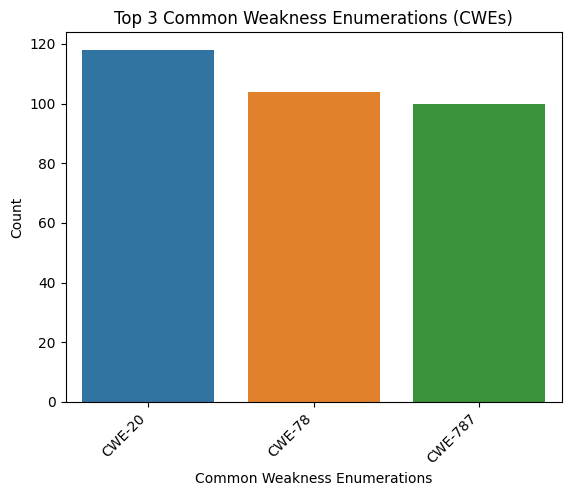

In [30]:
# Plot a bar chart showing the "Top 3 Common Weakness Enumerations (CWEs)"

sns.barplot(x="cwes",
    y="count", 
    hue="cwes",
    data=cwe_count,
    palette="tab10",
    legend=False
)

plt.xticks(rotation=45, ha="right")
plt.xlabel("Common Weakness Enumerations")
plt.ylabel("Count")
plt.title("Top 3 Common Weakness Enumerations (CWEs)")

plt.show()
plt.close()

[CWE-20](https://cwe.mitre.org/data/definitions/20.html) refers to Improper Input Validation: "the product receives input or data, but it does not validate or incorrectly validates that the input has the properties that are required to process the data safely and correctly." 

[CWE-78](https://cwe.mitre.org/data/definitions/78.html) refers to Improper Neutralization of Special Elements used in an OS Command ('OS Command Injection'): "the product constructs all or part of an OS command using externally-influenced input from an upstream component, but it does not neutralize or incorrectly neutralizes special elements that could modify the intended OS command when it is sent to a downstream component."

[CWE-787](https://cwe.mitre.org/data/definitions/787.html) refers to Out-of-bounds Write: "the product writes data past the end, or before the beginning, of the intended buffer."

All of these weaknesses are also listed in the 2025 list of the ["Top 25 Most Dangerous Software Weaknesses"](https://cwe.mitre.org/data/definitions/1435.html), as provided by the official CWE website. These weaknesses appear to be simple programming oversights or bugs, which could be mitigated in the future by peer review.

### Which 3 common weakness enumerations (CWEs) are most associated with ransomware?

In [31]:
# Construct a dataframe including only known ransomware campaigns

known_ransom = (
    kev[kev["known_ransomware_campaign_use"] == "Known"]
    .reset_index()
)

print(known_ransom)

     index          cve_id vendor_project  \
0       16  CVE-2026-35273         Oracle   
1       22  CVE-2026-50751    Check Point   
2       29  CVE-2026-48027             Nx   
3       30  CVE-2026-45321       TanStack   
4       49  CVE-2026-41940        WebPros   
..     ...             ...            ...   
348   1624  CVE-2021-21972         VMware   
349   1625  CVE-2021-21985         VMware   
350   1625  CVE-2021-21985         VMware   
351   1625  CVE-2021-21985         VMware   
352   1631  CVE-2021-40539           Zoho   

                                      product  \
0           PeopleSoft Enterprise PeopleTools   
1                            Security Gateway   
2                                  Nx Console   
3                                    TanStack   
4    cPanel & WHM and WP2 (WordPress Squared)   
..                                        ...   
348                            vCenter Server   
349                            vCenter Server   
350               

In [32]:
# Count occurences of each CWE

cwe_count_known_ransom = (
    known_ransom["cwes"]
    .value_counts()
    .head(3)
    .reset_index()
)

print(cwe_count_known_ransom)

      cwes  count
0   CWE-22     25
1   CWE-20     24
2  CWE-502     23


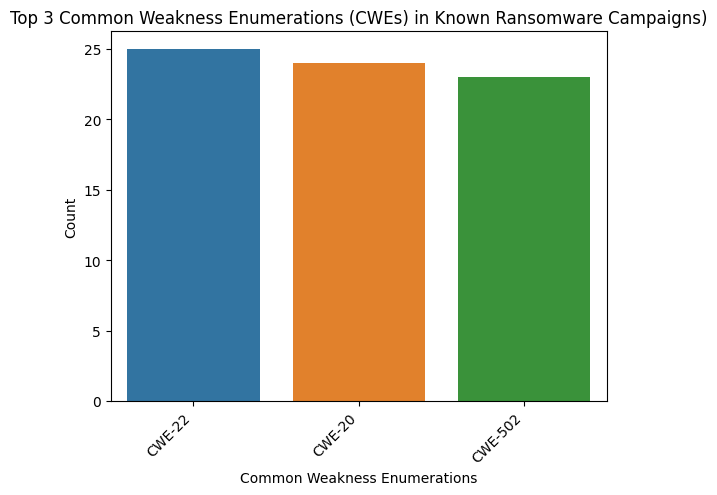

In [33]:
# Plot a bar chart showing the "Top 3 Common Weakness Enumerations (CWEs) in Known Ransomware Campaigns"

sns.barplot(x="cwes",
    y="count", 
    hue="cwes",
    data=cwe_count_known_ransom,
    palette="tab10",
    legend=False
)


plt.xticks(rotation=45, ha="right")
plt.xlabel("Common Weakness Enumerations")
plt.ylabel("Count")
plt.title("Top 3 Common Weakness Enumerations (CWEs) in Known Ransomware Campaigns)")

plt.show()
plt.close()

[CWE-22](https://cwe.mitre.org/data/definitions/22.html) refers to Improper Limitation of a Pathname to a Restricted Directory ('Path Traversal'): "the product uses external input to construct a pathname that is intended to identify a file or directory that is located underneath a restricted parent directory, but the product does not properly neutralize special elements within the pathname that can cause the pathname to resolve to a location that is outside of the restricted directory."

[CWE-20](https://cwe.mitre.org/data/definitions/20.html) refers to Improper Input Validation: "the product receives input or data, but it does not validate or incorrectly validates that the input has the properties that are required to process the data safely and correctly." 

[CWE-502](https://cwe.mitre.org/data/definitions/502.html) refers to Deserialization of Untrusted Data: "the product deserializes untrusted data without sufficiently ensuring that the resulting data will be valid."

These three CWEs all involve trusting or mishandling externally-sourced input. The prominence of these CWEs among ransomware-associated vulnerabilities suggests that weaknesses in processing untrusted input are frequently exploited during ransomware campaigns.

### How much time does CISA typically allow organizations to remediate known exploited vulnerabilities?

In [34]:
kev["remediation_days"] = (
    kev["due_date"] - kev["date_added"]
).dt.days

print("The average number of remediation days is " + str(int(kev["remediation_days"].mean())) + ".")

The average number of remediation days is 43.


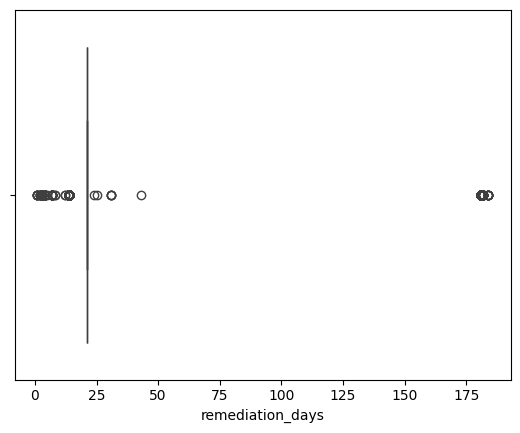

In [35]:
sns.boxplot(x="remediation_days", data=kev)
plt.show()
plt.close()

In [36]:
# Calculating quartiles for the remediation days column

q1_kev = kev["remediation_days"].quantile(0.25)
q3_kev = kev["remediation_days"].quantile(0.75)
iqr_kev = q3_kev - q1_kev

lower_bound_kev = q1_kev - (1.5 * iqr_kev)
upper_bound_kev = q3_kev + (1.5 * iqr_kev)

In [37]:
print(f"Q1: {q1_kev}")
print(f"Q3: {q3_kev}")
print(f"IQR: {iqr_kev}")
print(f"Lower bound: {lower_bound_kev}")
print(f"Upper bound: {upper_bound_kev}")

print()

print(kev["remediation_days"].value_counts().sort_index())

Q1: 21.0
Q3: 21.0
IQR: 0.0
Lower bound: 21.0
Upper bound: 21.0

remediation_days
1         6
2         5
3        51
4         8
5         1
7        22
8         2
12        2
14      295
21     1073
24        1
25        1
31        4
43        1
181     246
182      11
184       8
Name: count, dtype: int64


After examining the spread of the numbers more closely, I see that 21 days has a disproportionately high number of occurences, with other peaks at 14 and 181 days. These spikes suggest that CISA typically uses standardized deadlines (14, 21, and 181 days). This would explain the atypical results given by the boxplot, as well as the quartile numbers.

### How much time does CISA typically allow organizations to remediate known exploited vulnerabilities in the case of a known randsomware campaign?

In [38]:
known_ransom["remediation_days"] = (
    known_ransom["due_date"] - known_ransom["date_added"]
).dt.days

print("The average number of remediation days for known ransomware campaigns is " + str(int(known_ransom["remediation_days"].mean())) + ".")

The average number of remediation days for known ransomware campaigns is 45.


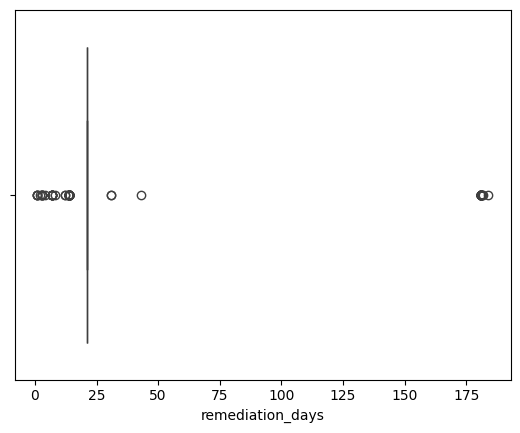

In [39]:
# Create a boxplot to visualize the expected number of remediation days 
sns.boxplot(x="remediation_days", data=known_ransom)
plt.show()
plt.close()

CISA appears to use a nearly identical remediation timeline for ransomware-related vulnerabilities as for the overall set of known exploited vulnerabilities.

I expected the timelines for all known vulnerabilities and ransomware-exploited vulnerabilities to differ noticeably; I assumed timelines would be steeper in the case of ransomware. However, the resulting boxplots appeared nearly identical. 

After verifying the summary statistics for each dataset, I saw that more than half of the observations in each dataset had remediation periods of 21 days, producing identical quartiles. Because the interquartile range was 0, nearly every value outside 21 was treated like an outlier by the boxplot. 

This confirmed that the visualization was accurately representing the data rather than exposing a bug in the analysis.

### How has the number of exploited vulnerabilities changed over time?

In [40]:
# Make a column for the year each vulnerability was added to the catalog
kev["year_added"] = kev["date_added"].dt.year
    
vulnerabilities_by_year = (
    kev.groupby("year_added")
       .size()
       .reset_index(name="count")
)

print(vulnerabilities_by_year)

   year_added  count
0        2021    341
1        2022    595
2        2023    194
3        2024    189
4        2025    255
5        2026    163


<Axes: xlabel='year_added', ylabel='count'>

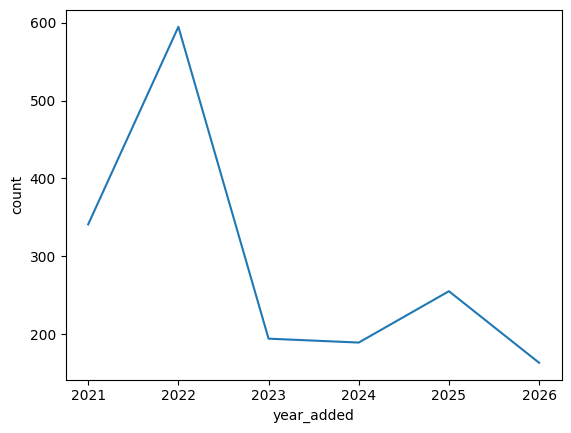

In [41]:
sns.lineplot(
    x="year_added",
    y="count",
    data=vulnerabilities_by_year
)

The catalog expanded rapidly during 2022 before leveling off in later years. Because the KEV catalog was established relatively recently, additional years of data will be needed before long-term trends can be confidently assessed.

## Conclusion
- Microsoft has the largest number of cataloged vulnerabilities.
- Input validation and use-after-free are the most common weaknesses.
- Ransomware vulnerabilities show similar remediation timelines to the broader catalog.
- Most remediation deadlines are exactly 21 days.
- Vulnerability additions peaked in 2022.